In [34]:
import pandas as pd

columns = ["unit", "time", "op1", "op2", "op3",
           "sensor1", "sensor2", "sensor3", "sensor4", "sensor5",
           "sensor6", "sensor7", "sensor8", "sensor9", "sensor10",
           "sensor11", "sensor12", "sensor13", "sensor14", "sensor15",
           "sensor16", "sensor17", "sensor18", "sensor19", "sensor20", "sensor21"]


train_files = ["CMAPSSData/train_FD001.txt", "CMAPSSData/train_FD002.txt",
               "CMAPSSData/train_FD003.txt", "CMAPSSData/train_FD004.txt"]

train_list = []

for i, file in enumerate(train_files):
    df_temp = pd.read_csv(file, sep=" ", header=None, names=columns + ["_1", "_2", "_3"], engine="python")
    df_temp["unit"] = df_temp["unit"] + (i * 1000)
    df_temp = df_temp.drop(columns=["_1", "_2", "_3"])
    train_list.append(df_temp)

df_train = pd.concat(train_list, ignore_index=True)


test_files = ["CMAPSSData/test_FD001.txt", "CMAPSSData/test_FD002.txt",
              "CMAPSSData/test_FD003.txt", "CMAPSSData/test_FD004.txt"]

test_list = []

for i, file in enumerate(test_files):
    df_temp = pd.read_csv(file, sep=" ", header=None, names=columns + ["_1", "_2", "_3"], engine="python")
    df_temp["unit"] = df_temp["unit"] + (i * 1000)
    df_temp = df_temp.drop(columns=["_1", "_2", "_3"])
    test_list.append(df_temp)

df_test = pd.concat(test_list, ignore_index=True)

In [35]:
grouped_by_unit = df_train.groupby("unit")
max_cycle = grouped_by_unit["time"].max()
df_train = df_train.merge(max_cycle.to_frame(name="max_cycle"), left_on="unit", right_index=True)
df_train["remaining"] = df_train["max_cycle"] - df_train["time"]
df_train = df_train.drop(columns=["max_cycle"])

print(df_train.shape)
print(list(df_train.columns))

X = df_train.drop(columns=["unit","time","op1", "op2","op3"])
print(X.shape)

Y = X.pop("remaining")

print(X.shape)

(160359, 27)
['unit', 'time', 'op1', 'op2', 'op3', 'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21', 'remaining']
(160359, 22)
(160359, 21)


In [36]:

X_test = df_test.groupby("unit"). \
    last().reset_index() \
    .drop(columns=["unit", "time", "op1", "op2", "op3"], axis=1)
    
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2)

print(X_train.shape)


(128287, 21)


The idea is to start with vectors with size of 21. The current activation function choice is ReLU activation. To avoid overfitting a dropout layer will be introduced.

In [37]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Normalization, Rescaling, TextVectorization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [38]:
model = keras.Sequential()
model.add(keras.Input(shape=(21,)))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())



In [39]:
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(512, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))

In [40]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer, loss='mean_absolute_error')

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,201 (2.39 MB)

 Trainable params: 627,137 (2.39 MB)

 Non-trainable params: 64 (256.00 B)

In [41]:
train_log = model.fit(x=X_train,y=Y_train,
                    validation_data = (X_val,Y_val),
                    epochs = 50,
                    shuffle = True)

Epoch 1/50
  11/4009 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 101.8314      

KeyboardInterrupt: 

In [42]:
y_pred = model.predict(X_test)
print(y_pred)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[4137.543 ]
 [4134.663 ]
 [4138.2246]
 [4135.375 ]
 [4136.4717]
 [4140.5024]
 [4147.978 ]
 [4135.1235]
 [4137.88  ]
 [4140.7236]
 [4129.7524]
 [4148.5845]
 [4145.2334]
 [4127.9243]
 [4139.166 ]
 [4143.9155]
 [4158.6167]
 [4137.992 ]
 [4140.6484]
 [4142.699 ]
 [4156.382 ]
 [4140.0015]
 [4136.37  ]
 [4186.9707]
 [4136.619 ]
 [4150.414 ]
 [4133.6313]
 [4139.1562]
 [4147.772 ]
 [4136.0786]
 [4154.509 ]
 [4163.7036]
 [4144.05  ]
 [4130.5605]
 [4150.9854]
 [4138.888 ]
 [4129.4707]
 [4154.8496]
 [4146.3345]
 [4142.0225]
 [4127.554 ]
 [4126.964 ]
 [4138.9727]
 [4141.1016]
 [4140.597 ]
 [4150.4473]
 [4131.5503]
 [4137.539 ]
 [4134.6436]
 [4143.7896]
 [4136.3423]
 [4171.3135]
 [4163.786 ]
 [4144.7764]
 [4138.576 ]
 [4126.5977]
 [4135.728 ]
 [4135.948 ]
 [4141.1387]
 [4136.8457]
 [4142.454 ]
 [4155.29  ]
 [4136.5864]
 [4136.956 ]
 [4145.8   ]
 [4176.501 ]
 [4138.736 ]
 [4154.4697]
 [4132.284 ]
 [4138.008 ]
 [4145.3   ]
 [4148.287 ]
 [4140.919 ]
 [4139.6924]

In [43]:
rul_list = []
rul_files = ["CMAPSSData/RUL_FD001.txt", "CMAPSSData/RUL_FD002.txt", "CMAPSSData/RUL_FD003.txt", "CMAPSSData/RUL_FD004.txt"]

for i, rul_file in enumerate(rul_files):
    rul_values = pd.read_csv(rul_file, header=None).squeeze()
    units = pd.Series(range(1, len(rul_values) + 1)) + (i * 1000)
    df_rul = pd.DataFrame({'unit': units, 'RUL': rul_values})
    rul_list.append(df_rul)

df_rul = pd.concat(rul_list, ignore_index=True)

X_test = df_test.groupby("unit").last().reset_index().drop(columns=["unit", "time", "op1", "op2", "op3"])

y_test = df_rul.set_index('unit').loc[df_test.groupby("unit").last().reset_index()["unit"]]["RUL"].values

y_pred = model.predict(X_test)



23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 4066.7564623022013
MSE: 16544142.476889886
RMSE: 4067.4491363617426


MAE: 28.83614503814611
MSE: 1395.4535651525744
RMSE: 37.35577017212434

L2 Regularization might help because the validation loss was a lot larger than the training loss, with a small regularization parameter. Increased learning rate to avoid getting stuck, but the model was likely overshooting minima. 

In [47]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout

model = keras.Sequential()
model.add(keras.Input(shape=(21,)))

model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(1, kernel_regularizer=regularizers.l2(0.001)))

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


In [48]:
model.compile(optimizer=optimizer, loss='mean_absolute_error')

train_log = model.fit(
    x=X_train,y=Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=32,
    shuffle=True
)

Epoch 1/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 58.5124 - val_loss: 643.4322
Epoch 2/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 50.1839 - val_loss: 114.4867
Epoch 3/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 47.8382 - val_loss: 111.7099
Epoch 4/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - loss: 47.2198 - val_loss: 134.2702
Epoch 5/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - loss: 46.6181 - val_loss: 112.6577
Epoch 6/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - loss: 46.1797 - val_loss: 109.0566
Epoch 7/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 45.5939 - val_loss: 102.2491
Epoch 8/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 44.8590 - val_loss: 70.2216
Epoch 9/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 45.0220 - val_loss: 52.5910
Epoch 10/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 44.5654 - val_loss: 63.0959
Epoch 11/50
4009/4009 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 44.2822 - val_loss

In [50]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 27.144091131326334
MSE: 1260.382247051369
RMSE: 35.50186258566399


MAE: 27.144091131326334
MSE: 1260.382247051369
RMSE: 35.50186258566399

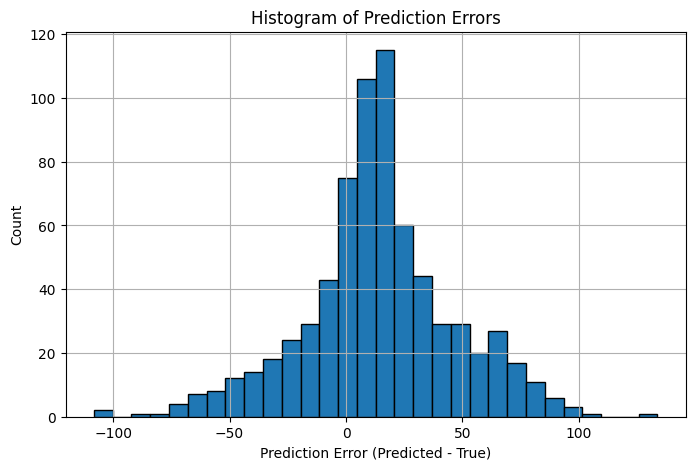

In [61]:
import matplotlib.pyplot as plt
import numpy as np
y_pred = y_pred.flatten()
y_true = y_test.flatten()
errors = y_pred - y_true
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel('Prediction Error (Predicted - True)')
plt.ylabel('Count')
plt.title('Histogram of Prediction Errors')
plt.grid(True)
plt.show()
